In [1]:
import sys
sys.path.insert(1, '/home/bricej/MyPythonLibrary/StageM2_IVT/library/')
import domain
from domain import *
from climbas import *
import numpy as np
import xarray as xr
import pandas as pd
from netCDF4 import Dataset
from scipy import stats
import scipy.stats as stats
import matplotlib.pyplot as plt

# Common period of all datasets

In [2]:
iyear = 1981
fyear = 2015

# Datasets used

In [3]:
models = ['APHRO','CHIRPS','CRU','ERA5','GPCP','HARv2']

# Annual Time series for precipitation datasets (Appendix 4)

Annual mean (temporally and spatially) is computed for every year available for the different datasets. For more details : '/home/bricej/MyPythonLibrary/StageM2_IVT/script/compute_timeseries_tp_{model}'

In [4]:
tp_datasets = {} # dictionnary to store precipitation time series

domain = 'HMA' # for all High Mountain Asia (HMA) (see definition in '/home/bricej/MyPythonLibrary/StageM2_IVT/library/domain.py')

path = '/bettik/PROJECTS/pr-regional-climate/bricej/results/timeseries/'

# APHRO
model=models[0]
tp_datasets[model] = {}
tp_datasets[model][domain] = pd.read_csv(path + f'timeseries_tp_annual_{domain}_1951-2015_{model}.csv')

# GPCP
model=models[4]
tp_datasets[model] = {}
tp_datasets[model][domain] = pd.read_csv(path + f'timeseries_tp_annual_{domain}_1891-2019_{model}.csv')

# CRU
model=models[2]
tp_datasets[model] = {}
tp_datasets[model][domain] = pd.read_csv(path + f'timeseries_tp_annual_{domain}_1901-2020_{model}.csv')

# CHIRPS
model=models[1]
tp_datasets[model] = {}
tp_datasets[model][domain] = pd.read_csv(path + f'timeseries_tp_annual_{domain}_1981-2024_{model}.csv')

# HARv2
model=models[5]
tp_datasets[model] = {}
tp_datasets[model][domain] = pd.read_csv(path + f'timeseries_tp_annual_{domain}_1980-2023_{model}.csv')

# ERA5
model=models[3]
tp_datasets[model] = {}
tp_datasets[model][domain] = pd.read_csv(path + f'timeseries_tp_annual_{domain}_1940-2025_{model}.csv')

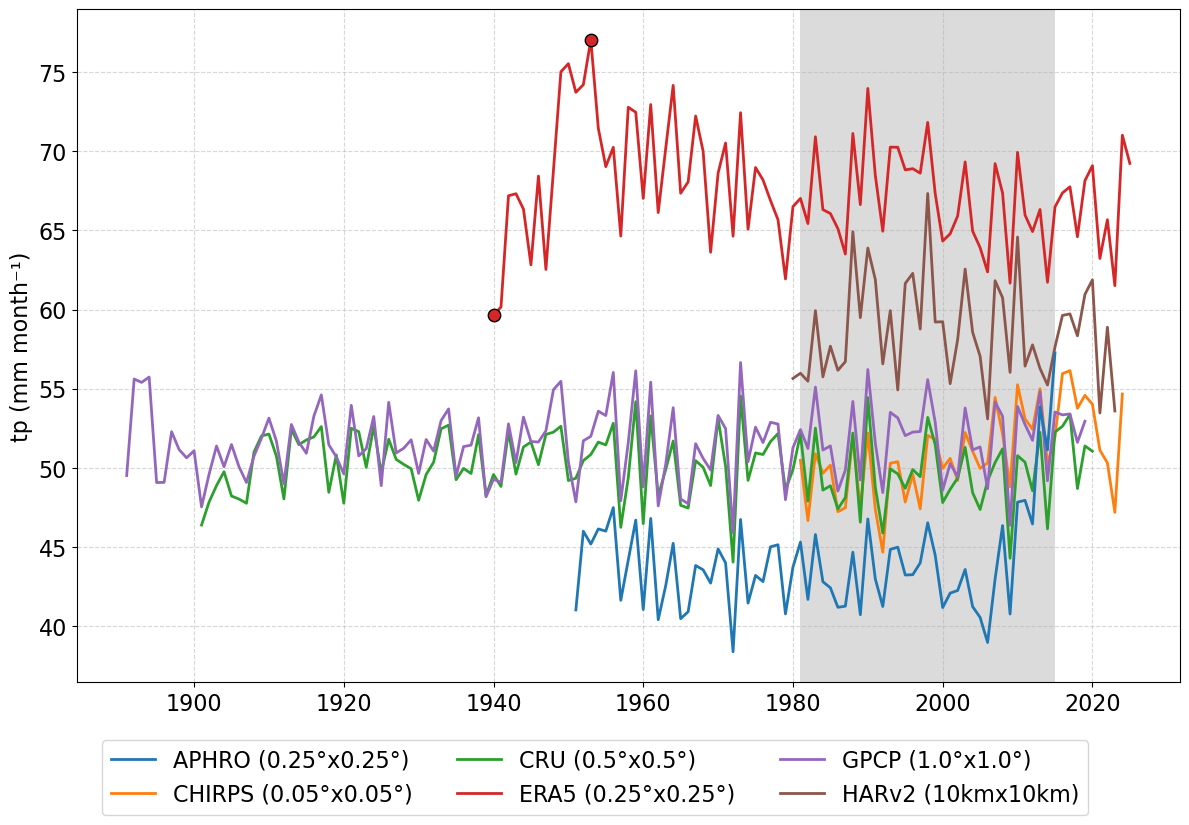

In [5]:
# spatial resolution for every dataset for the legend
resolutions = {'APHRO': '0.25°x0.25°',
               'GPCP': '1.0°x1.0°',
               'CRU': '0.5°x0.5°',
               'CHIRPS': '0.05°x0.05°',
               'HARv2': '10kmx10km',
               'ERA5': '0.25°x0.25°'}

# domain
dom='HMA'

# ====================== plot time series ========================

# figure
fig, ax = plt.subplots(figsize=(12,8))

for model in models:
    da = tp_datasets[model][dom]

    # to make every line really seen
    if model == 'APHRO':
        ax.plot(da['year'], da['tp'], linestyle='-', label=f'{model} ({resolutions[model]})', linewidth=2, zorder=10)
    else:
        ax.plot(da['year'], da['tp'], linestyle='-', label=f'{model} ({resolutions[model]})', linewidth=2, zorder=2)

    if model == 'ERA5':
        imax = np.argmax(da['tp']) # indice du maximum de ERA5
        imin = np.argmin(da['tp']) # indice du minimum de ERA5
        ax.scatter(da['year'][imax], da['tp'][imax], color='tab:red', s=80, edgecolor='black', zorder=10) # point pour max
        ax.scatter(da['year'][imin], da['tp'][imin], color='tab:red', s=80, edgecolor='black', zorder=10) # point pour min

ax.set_ylabel('tp (mm month⁻¹)', fontsize=16)
ax.tick_params(labelbottom=True, labelsize=16)
ax.grid(True, linestyle='--', alpha=0.5)

# common period for al datasets : 1981-2015
ax.axvspan(1981,2015,color='lightgray',alpha=0.8,zorder=0,ec=None)

# legend
handles, labels = ax.get_legend_handles_labels()
fig.legend(handles,labels,loc='lower center',bbox_to_anchor=(0.5, -0.04),ncol=3,fontsize=16,frameon=True)

plt.tight_layout(rect=[0,0.08,1,1]) # [left, bottom, right, top]
plt.show()

Figure A4. Annual precipitation time series over High Mountain Asia (HMA) derived from the different datasets : dataset characteristics are summarized in Table 1. The gray shaded region indicates the period common to all datasets (1981–2015). Red dots indicate the minimum and maximum annual precipitation values in ERA5. The red bold numbers shown above the red line represent the precipitation standard deviation in mm.month-1 for the periods 1940–1960 and 1960–2025, respectively.